# Analysis of the candidates
**Purpose**</br>
To analyze the individual candidates and their representations across the various experiments implemented where the exeriments vary the window slab size and lower threshold growth thresholds at fixed high detection threshold 4.2.

**Databases**
- combined_candidates: *The dragnet of all candidate particles identified in the experiemnts. Because multiple experiments were ran on each cell, this listing will contain multiple entries per unique particle but will have a different feature set because of the differing experimental parameters. Also carries the classifier's scores directly (`ml_prob`, `cluster_root`, `cluster_ml_label`, `in_sample`, ...) for slab_thickness 21/23/25, kept current by running `ml_classifier/update_combined_candidates_scores.py` after each retrain.*

# Refresh the candidate linking if labels have been updated

In [33]:
relink_ = False
if relink_:
    !cd .. && uv run python -m candidate_linking.link_candidates \
        --data-dir Data/experiments \
        --out Data/candidate_linking/clusters.csv \
        --instance-map-out Data/candidate_linking/instance_to_cluster.csv

In [ ]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    fbeta_score,
    average_precision_score,
)

sys.path.append(str(Path.cwd().parent))

plt.rcParams.update(
    {
        "font.size": 14,  # base size (ticks, legend text default to this)
        "axes.labelsize": 14,  # xlabel/ylabel
        "axes.titlesize": 16,  # title
        "legend.fontsize": 14,
    }
)

classifier_dir = Path("../ml_classifier")
cfg = toml.load("../config.toml")

id_cols = ["experiment_number", "volume_name", "peak_z", "peak_y", "peak_x"]
con = duckdb.connect()
df_scored = con.sql(f"""
    SELECT {", ".join(id_cols)}, particle, slab_thickness, low_threshold_scale,
           cluster_root, cluster_ml_label, in_sample, ml_prob
    FROM read_csv_auto('../Data/experiments/combined_candidates.csv')
    WHERE slab_thickness IN (21, 23, 25)
""").df()
print(f"{len(df_scored)} rows, {df_scored['cluster_root'].nunique()} unique particles "
      f"(slab_thickness 21/23/25, direct from combined_candidates.csv)")

# Analysis of the experimental configs from the trained classifier

## Break out theh TP and FP candidates per the labels

In [18]:
df_TP = df_scored[df_scored["particle"].isin([1, 2, 3])]
df_FP = df_scored[df_scored["particle"] == 0]

print(f"TP instances: {len(df_TP)}, {df_TP['in_sample'].mean():.0%}")
print(f"FP instances: {len(df_FP)}, {df_FP['in_sample'].mean():.0%}")

print(f"Number of unique TPs: {df_TP['cluster_root'].nunique()}")
print(f"Number of unique FPs: {df_FP['cluster_root'].nunique()}")

TP instances: 7721, 57%
FP instances: 11720, 86%
Number of unique TPs: 793
Number of unique FPs: 1486


## Distribution per config

In [19]:
TP_by_config = df_TP.groupby(["slab_thickness", "low_threshold_scale"])["ml_prob"].describe()
FP_by_config = df_FP.groupby(["slab_thickness", "low_threshold_scale"])["ml_prob"].describe()

print("TP - configs ranked by median prob:")
print(TP_by_config[["50%", "25%", "75%", "count"]].sort_values("50%", ascending = False))
print("\n\n")
print("FP - configs ranked by median prob:")
print(FP_by_config[["50%", "25%", "75%", "count"]].sort_values("50%", ascending = False))

TP - configs ranked by median prob:
                                         50%       25%       75%  count
slab_thickness low_threshold_scale                                     
25             2.75                 0.998086  0.989118  0.999506  653.0
               2.50                 0.998003  0.989759  0.999504  643.0
               3.00                 0.997922  0.987804  0.999494  660.0
23             2.75                 0.997848  0.988954  0.999472  700.0
               3.00                 0.997772  0.988494  0.999443  700.0
               2.50                 0.997768  0.988235  0.999462  693.0
21             2.75                 0.997588  0.987073  0.999425  751.0
               2.50                 0.997580  0.986884  0.999415  746.0
               3.00                 0.997425  0.987163  0.999417  754.0
23             3.25                 0.997296  0.986311  0.999426  708.0
               3.50                 0.996978  0.980166  0.999327  713.0



FP - configs ranked by me

## Separation metrics

In [28]:
from sklearn.metrics import f1_score


labeled = pd.concat([df_TP.assign(y=1), df_FP.assign(y=0)])
def config_auc(df: pd.DataFrame) -> float:
  return roc_auc_score(df["y"], df["ml_prob"])

def recall(df: pd.DataFrame) -> float:
  return recall_score(df["y"], df["ml_prob"] > 0.5)

def precision(df: pd.DataFrame) -> float:
  return precision_score(df["y"], df["ml_prob"] > 0.5)

def f1(df: pd.DataFrame) -> float:
  return f1_score(df["y"], df["ml_prob"] > 0.5)

def config_pr_auc(df: pd.DataFrame) -> float:
  return average_precision_score(df["y"], df["ml_prob"])
auc_by_config = (
    labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(config_auc, include_groups=False)
    .sort_values(ascending=False)
)
print("AUC by config:")
print(auc_by_config)

recall_by_config = (
    labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(recall, include_groups=False)
    .sort_values(ascending=False)
)

print()
print("Recall by config:")
print(recall_by_config)

precision_by_config = (
    labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(precision, include_groups=False)
    .sort_values(ascending=False)
)
print()
print("Precision by config:")
print(precision_by_config)

f1_by_config = (
    labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(f1, include_groups=False)
    .sort_values(ascending=False)
)
print()
print("F1 by config:")
print(f1_by_config)

pr_auc_by_config = (
    labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(config_pr_auc, include_groups=False)
    .sort_values(ascending=False)
)
print()
print("PR AUC by config:")
print(pr_auc_by_config)



AUC by config:
slab_thickness  low_threshold_scale
25              2.75                   0.998338
                3.00                   0.998236
                2.50                   0.998229
23              3.00                   0.997554
                2.75                   0.997514
                3.25                   0.996736
                3.50                   0.996376
                2.50                   0.995993
21              3.00                   0.995780
                2.75                   0.995639
                2.50                   0.994823
dtype: float64

Recall by config:
slab_thickness  low_threshold_scale
25              2.50                   0.950233
21              3.00                   0.945623
                2.75                   0.945406
                2.50                   0.945040
23              2.50                   0.943723
                2.75                   0.942857
25              3.00                   0.942424
               

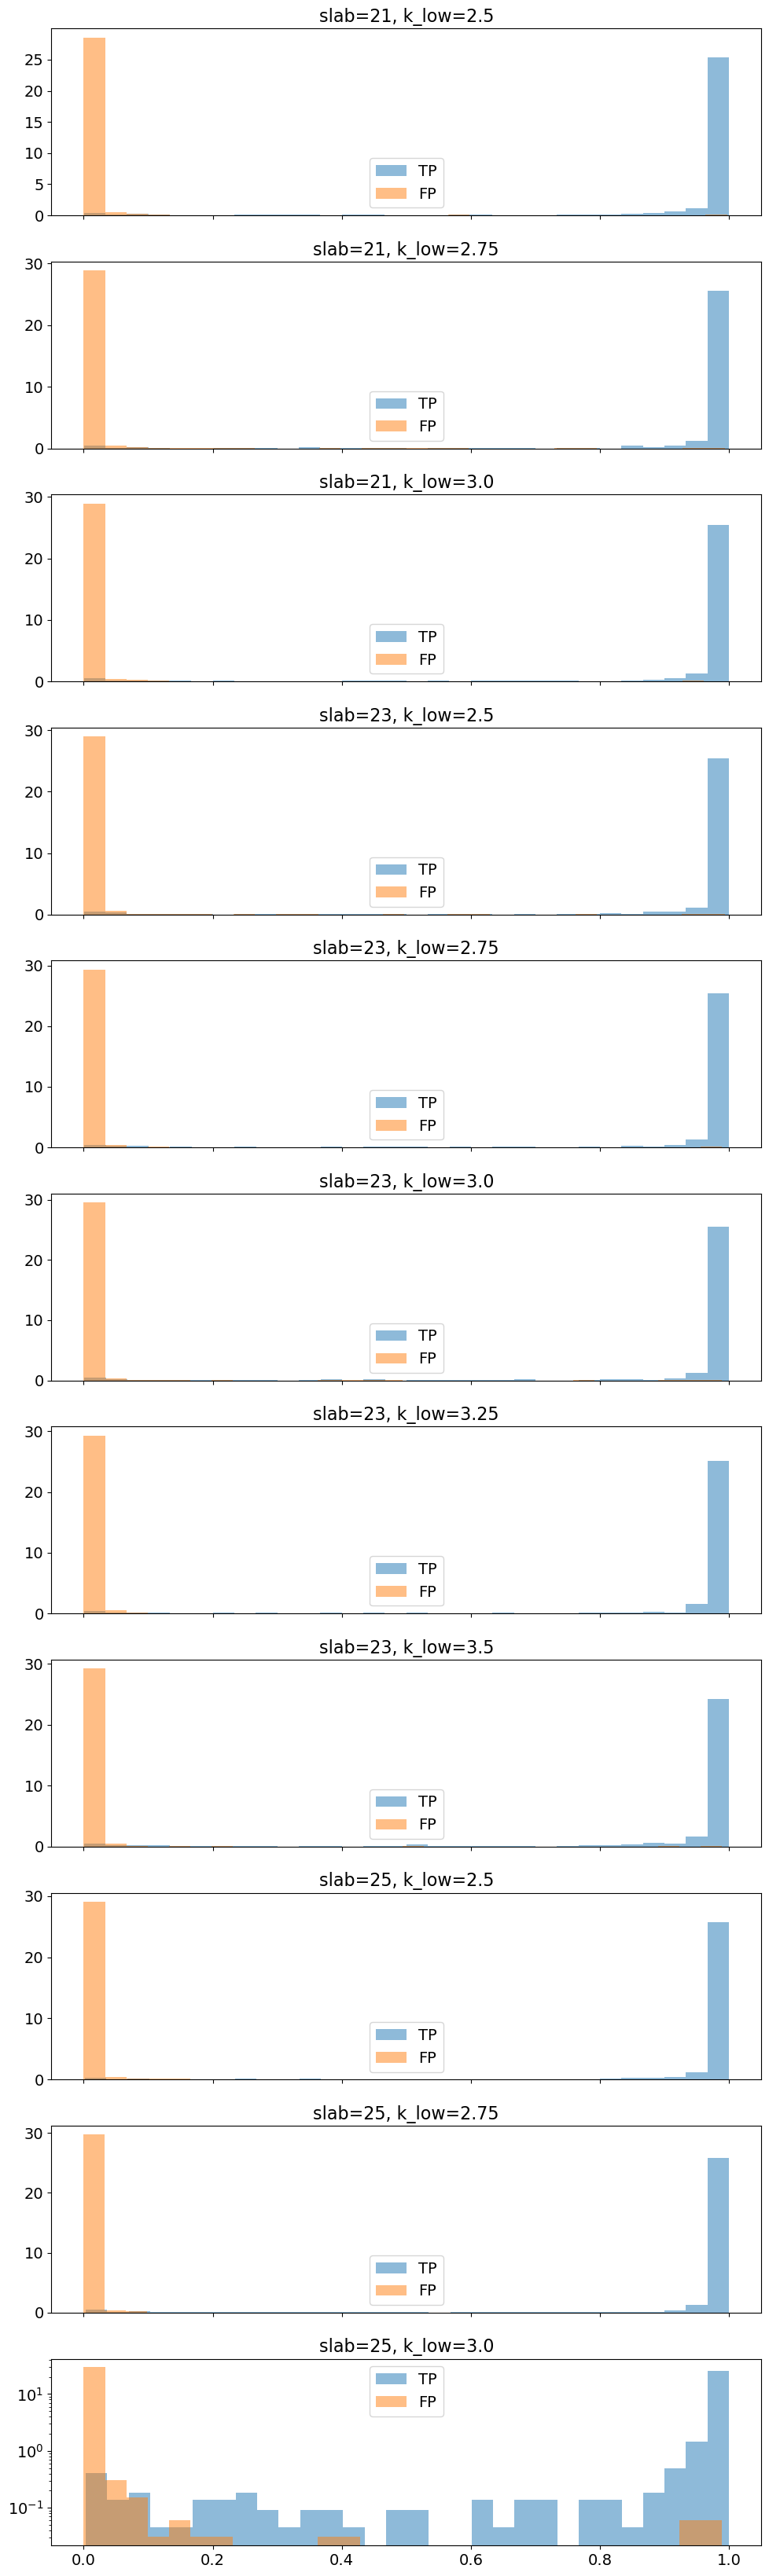

In [22]:
configs = sorted(df_scored[["slab_thickness","low_threshold_scale"]].drop_duplicates().itertuples(index=False))
fig, axes = plt.subplots(len(configs), 1, figsize=(10, 3*len(configs)), sharex=True)
for ax, (slab, klow) in zip(axes, configs):
    ax.hist(df_TP[(df_TP.slab_thickness==slab)&(df_TP.low_threshold_scale==klow)]["ml_prob"], bins=30, alpha=0.5, label="TP", density=True)
    ax.hist(df_FP[(df_FP.slab_thickness==slab)&(df_FP.low_threshold_scale==klow)]["ml_prob"], bins=30, alpha=0.5, label="FP", density=True)
    ax.set_title(f"slab={slab}, k_low={klow}")
    ax.legend()
plt.yscale("log")
plt.tight_layout()

# Cross-Validation Analysis

**Why**: `ml_prob` above comes from `model.joblib`, which was fit on essentially all of these same TP/FP rows (see `ml_classifier/train_classifier.py`) — those scores are in-sample and optimistic, not a fair read of which config actually separates TP from FP best. This section reruns the same 5-fold `StratifiedGroupKFold`-by-`volume_name` cross-validation `train_classifier.py` uses, but inline here, so we get an honest out-of-fold probability per row to compare against the in-sample numbers above.

Built against the *current* labels/clusters (`df_scored`'s `in_sample` / `cluster_ml_label`, computed from this morning's reclustering) rather than `ml_classifier/training_table.csv`, which is stale as of a labeling batch reviewed since the model was last trained (951 backlog rows moved from unreviewed into real TP/FP/needs-review calls) -- so this also incidentally gives a training set 951-labels more current than what's deployed.

In [ ]:
import duckdb
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import average_precision_score, brier_score_loss

from ml_classifier.features import (
    FEATURE_COLUMNS,
    REQUIRED_RAW_COLUMNS,
    add_unit_normalized_features,
    load_cell_meta,
)

cell_meta = load_cell_meta(Path("../config.toml"))

id_cols = ["experiment_number", "volume_name", "peak_z", "peak_y", "peak_x"]
train_keys = df_scored.loc[
    df_scored["in_sample"],
    id_cols + ["slab_thickness", "low_threshold_scale", "cluster_root", "cluster_ml_label"],
]
print(f"CV-eligible instances (current labels/clusters): {len(train_keys)}, "
      f"{train_keys['cluster_root'].nunique()} unique particles")

con = duckdb.connect()
slab_list = ",".join(str(s) for s in (21, 23, 25))
raw_cols = ", ".join(c for c in REQUIRED_RAW_COLUMNS if c not in id_cols)
raw_features = con.sql(f"""
    SELECT {", ".join(id_cols)}, {raw_cols}
    FROM read_csv_auto('../Data/experiments/combined_candidates.csv')
    WHERE slab_thickness IN ({slab_list})
""").df()

cv_df = train_keys.merge(raw_features, on=id_cols, how="inner")
assert len(cv_df) == len(train_keys), "lost rows joining back to raw features"
cv_df = add_unit_normalized_features(cv_df, cell_meta)

counts = cv_df.groupby("cluster_root")["cluster_root"].transform("count")
cv_df["sample_weight"] = 1.0 / counts
print(f"built CV frame: {len(cv_df)} rows, {cv_df['cluster_root'].nunique()} particles, "
      f"{(cv_df['cluster_ml_label']==1).sum()} TP / {(cv_df['cluster_ml_label']==0).sum()} FP")


In [ ]:
X = cv_df[FEATURE_COLUMNS].to_numpy()
y = cv_df["cluster_ml_label"].to_numpy().astype(int)
w = cv_df["sample_weight"].to_numpy()
groups = cv_df["volume_name"].to_numpy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
oof_prob = np.zeros(len(cv_df))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups)):
    held_out = sorted(set(groups[test_idx]))
    model = HistGradientBoostingClassifier(random_state=0)
    model.fit(X[train_idx], y[train_idx], sample_weight=w[train_idx])
    prob = model.predict_proba(X[test_idx])[:, 1]
    oof_prob[test_idx] = prob
    fold_ap = average_precision_score(y[test_idx], prob, sample_weight=w[test_idx])
    print(f"fold {fold}: {len(held_out)} held-out volumes, {len(test_idx)} rows, PR-AUC={fold_ap:.3f}")

cv_df["oof_prob"] = oof_prob

overall_ap = average_precision_score(y, oof_prob, sample_weight=w)
overall_brier = brier_score_loss(y, oof_prob, sample_weight=w)
print(f"\nout-of-fold PR-AUC (weighted):  {overall_ap:.3f}")
print(f"out-of-fold Brier (weighted, lower is better): {overall_brier:.3f}")
print("(compare to train_classifier.py's last reported CV run for drift)")


## Per-config comparison (honest, out-of-fold) — compare against the in-sample tables above

In [ ]:
cv_TP = cv_df[cv_df["cluster_ml_label"] == 1]
cv_FP = cv_df[cv_df["cluster_ml_label"] == 0]

oof_TP_by_config = cv_TP.groupby(["slab_thickness", "low_threshold_scale"])["oof_prob"].describe()
oof_FP_by_config = cv_FP.groupby(["slab_thickness", "low_threshold_scale"])["oof_prob"].describe()

print("TP (out-of-fold) — configs ranked by median prob:")
print(oof_TP_by_config[["50%", "25%", "75%", "count"]].sort_values("50%", ascending=False))
print("\nFP (out-of-fold) — configs ranked by median prob:")
print(oof_FP_by_config[["50%", "25%", "75%", "count"]].sort_values("50%"))

def config_auc(g):
    return roc_auc_score(g["cluster_ml_label"], g["oof_prob"]) if g["cluster_ml_label"].nunique() == 2 else float("nan")

oof_auc_by_config = (
    cv_df.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(config_auc, include_groups=False)
    .sort_values(ascending=False)
)
print("\nOut-of-fold AUC by config (compare ranking to the in-sample AUC table above):")
print(oof_auc_by_config)


# Extending to all sweep windows (11, 15, 31 included) — raw-feature check, no model

The trained classifier only ever saw slab_thickness 21/23/25 (see `prepare_training_data.py`), so it can't be pointed at 11/15/31 without extrapolating out of its training distribution. This uses a raw pipeline feature (`snr_peak`) directly instead -- no model involved -- as a quick, cheap check of whether the "bigger window separates better" trend (23, 25 > 21) keeps going at 31, or reverses. Ground truth exists at all six slab_thicknesses (checked directly against `combined_candidates.csv`), so this is answerable today.

Using AUC rather than comparing raw `snr_peak` values directly across slab_thicknesses matters here: `slab_thickness` changes the Stage-1 background estimate, so the raw scale of `snr_peak` isn't guaranteed comparable across very different windows (the same reason training was restricted to 21/23/25) -- but AUC only depends on how well TP ranks above FP *within* a given slab_thickness, so it's unaffected by that scale shift.

In [ ]:
raw = pd.read_csv(
    "../Data/experiments/combined_candidates.csv",
    usecols=["particle", "slab_thickness", "low_threshold_scale", "snr_peak"],
)
raw_TP = raw[raw["particle"].isin([1, 2, 3])]
raw_FP = raw[raw["particle"] == 0]

print("TP snr_peak median by slab_thickness (all sweep windows, low_threshold_scale pooled):")
print(raw_TP.groupby("slab_thickness")["snr_peak"].median().sort_values(ascending=False))
print("\nFP snr_peak median by slab_thickness:")
print(raw_FP.groupby("slab_thickness")["snr_peak"].median().sort_values())

raw_labeled = pd.concat([raw_TP.assign(y=1), raw_FP.assign(y=0)])

auc_by_slab = (
    raw_labeled.groupby("slab_thickness")
    .apply(lambda g: roc_auc_score(g["y"], g["snr_peak"]), include_groups=False)
    .sort_values(ascending=False)
)
print("\nsnr_peak AUC by slab_thickness (all 6 sweep windows, low_threshold_scale pooled):")
print(auc_by_slab)

auc_by_full_config = (
    raw_labeled.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(lambda g: roc_auc_score(g["y"], g["snr_peak"]) if g["y"].nunique() == 2 else float("nan"), include_groups=False)
    .sort_values(ascending=False)
)
print("\nsnr_peak AUC by full (slab_thickness, low_threshold_scale) config:")
print(auc_by_full_config)


## Widened-scope experiment: retrain including slab_thickness 31

The raw single-feature check above (`snr_peak` AUC by slab_thickness) came back inconclusive -- it didn't even reproduce the 23/25 > 21 trend the real model shows, so it can't be trusted to say anything about 31. This section is the real test: rebuild the training pool with slab_thickness (21, 23, 25, 31) instead of just (21, 23, 25), and rerun the same 5-fold `StratifiedGroupKFold`-by-`volume_name` cross-validation.

**This is exploratory, not a change to the deployed model.** It does not touch `ml_classifier/model.joblib`, `ml_classifier/training_table.csv`, or `Data/experiments/combined_candidates.csv` -- all of that stays scoped to (21, 23, 25) per `prepare_training_data.py`'s documented design. This just answers "if we did widen it, would 31 help or hurt" using a real model instead of one raw feature.

In [ ]:
import ast

WIDER_SLAB_THICKNESSES = (21, 23, 25, 31)
SPIKED_CELLS = frozenset(f"M50L-{n:02d}" for n in range(16, 24))

clusters_current = pd.read_csv("../Data/candidate_linking/clusters.csv")
clusters_current["particle_labels"] = clusters_current["particle_labels"].apply(ast.literal_eval)

def _cluster_label(labels):
    labels = set(labels)
    has_tp = bool(labels & {1, 2, 3})
    has_fp = 0 in labels
    if has_tp and has_fp:
        return None
    if has_tp:
        return 1
    if has_fp:
        return 0
    return None

clusters_current["cluster_ml_label"] = clusters_current["particle_labels"].apply(_cluster_label)
label_map_wide = clusters_current.set_index("cluster_root")["cluster_ml_label"].to_dict()

instance_map = pd.read_csv("../Data/candidate_linking/instance_to_cluster.csv")

slab_list_wide = ",".join(str(s) for s in WIDER_SLAB_THICKNESSES)
extra_raw_cols = [c for c in REQUIRED_RAW_COLUMNS if c not in id_cols]
raw_wide = con.sql(f"""
    SELECT {", ".join(id_cols)}, slab_thickness, low_threshold_scale, {", ".join(extra_raw_cols)}
    FROM read_csv_auto('../Data/experiments/combined_candidates.csv')
    WHERE slab_thickness IN ({slab_list_wide})
""").df()
print(f"wider-window instances (slab {WIDER_SLAB_THICKNESSES}): {len(raw_wide)}")

raw_wide = raw_wide.merge(instance_map, on=id_cols, how="left")
raw_wide["cluster_ml_label"] = raw_wide["cluster_root"].map(label_map_wide)

spiked_tp = raw_wide["volume_name"].isin(SPIKED_CELLS) & (raw_wide["cluster_ml_label"] == 1)
wide_df = raw_wide[raw_wide["cluster_ml_label"].notna() & ~spiked_tp].copy()

wide_df = add_unit_normalized_features(wide_df, cell_meta)
counts = wide_df.groupby("cluster_root")["cluster_root"].transform("count")
wide_df["sample_weight"] = 1.0 / counts

print(f"widened training pool: {len(wide_df)} rows, {wide_df['cluster_root'].nunique()} particles, "
      f"{(wide_df['cluster_ml_label'] == 1).sum()} TP / {(wide_df['cluster_ml_label'] == 0).sum()} FP")
print(wide_df.groupby("slab_thickness")["cluster_ml_label"].value_counts())

In [ ]:
Xw = wide_df[FEATURE_COLUMNS].to_numpy()
yw = wide_df["cluster_ml_label"].to_numpy().astype(int)
ww = wide_df["sample_weight"].to_numpy()
groupsw = wide_df["volume_name"].to_numpy()

cvw = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
oof_prob_w = np.zeros(len(wide_df))

for fold, (train_idx, test_idx) in enumerate(cvw.split(Xw, yw, groups=groupsw)):
    held_out = sorted(set(groupsw[test_idx]))
    model_w = HistGradientBoostingClassifier(random_state=0)
    model_w.fit(Xw[train_idx], yw[train_idx], sample_weight=ww[train_idx])
    prob = model_w.predict_proba(Xw[test_idx])[:, 1]
    oof_prob_w[test_idx] = prob
    fold_ap = average_precision_score(yw[test_idx], prob, sample_weight=ww[test_idx])
    print(f"fold {fold}: {len(held_out)} held-out volumes, {len(test_idx)} rows, PR-AUC={fold_ap:.3f}")

wide_df["oof_prob"] = oof_prob_w
overall_ap_w = average_precision_score(yw, oof_prob_w, sample_weight=ww)
overall_brier_w = brier_score_loss(yw, oof_prob_w, sample_weight=ww)
print(f"\nout-of-fold PR-AUC (weighted, slab {WIDER_SLAB_THICKNESSES}): {overall_ap_w:.3f}")
print(f"out-of-fold Brier (weighted): {overall_brier_w:.3f}")

In [ ]:
def config_auc_w(g):
    return roc_auc_score(g["cluster_ml_label"], g["oof_prob"]) if g["cluster_ml_label"].nunique() == 2 else float("nan")

auc_by_config_w = (
    wide_df.groupby(["slab_thickness", "low_threshold_scale"])
    .apply(config_auc_w, include_groups=False)
    .sort_values(ascending=False)
)
print("Out-of-fold AUC by full config, including slab_thickness=31:")
print(auc_by_config_w)

auc_by_slab_w = (
    wide_df.groupby("slab_thickness")
    .apply(config_auc_w, include_groups=False)
    .sort_values(ascending=False)
)
print("\nOut-of-fold AUC pooled by slab_thickness only (compare 31 against 21/23/25):")
print(auc_by_slab_w)

# End of Candidate Analysis

# Distribution of SNR Peak
The SNR peak threshold of 4.2 is used for seeding, so a cluster at the smaller end could indicate reduction in sensitivity

In [ ]:
cf_TP.df["snr_peak"].hist(bins=50, figsize=(12, 6), alpha=0.5)
cf_FP.df["snr_peak"].hist(bins=50, figsize=(12, 6), alpha=0.5)
plt.title("SNR Peak Distribution for True Positives and False Positives")
plt.ylabel("Frequency")
plt.xlabel("SNR Peak")
plt.legend(["True Positives", "False Positives"])
plt.show()

# Distribution of Radial Position
We see a bi-modal distribution in the FPs near the core and can wall. This is where the assumption of axial symmetry breaks down.

In [ ]:
cf_TP.df["radial_pos"].hist(bins=50, figsize=(12, 6), alpha=0.5)
cf_FP.df["radial_pos"].hist(bins=50, figsize=(12, 6), alpha=0.5)
plt.title("Radial Position Distribution for True Positives and False Positives")
plt.ylabel("Frequency")
plt.xlabel("Radial Position")
plt.legend(["True Positives", "False Positives"])
plt.show()

In [ ]:
mid_x, mid_y = 1425 / 2, 1425 / 2
samples = 10
random_rows = candidate_frame.df.sample(n=samples, random_state=42)
radial_positions = random_rows["radial_pos"].reset_index(drop=True)
peak_z = random_rows["peak_z"].reset_index(drop=True)
peak_x = random_rows["peak_x"].reset_index(drop=True)
peak_y = random_rows["peak_y"].reset_index(drop=True)
centroid_x = random_rows["centroid_x"].reset_index(drop=True)
centroid_y = random_rows["centroid_y"].reset_index(drop=True)
centroid_z = random_rows["centroid_z"].reset_index(drop=True)
print(type(random_rows))


In [ ]:
for s in range(samples):
    radial_pos = radial_positions[s]
    peak_z_val, peak_x_val, peak_y_val = peak_z[s], peak_x[s], peak_y[s]
    cen_z, cen_x, cen_y = centroid_z[s], centroid_x[s], centroid_y[s]

    p_pos = np.linalg.norm([peak_x_val - mid_x, peak_y_val - mid_y])
    c_pos = np.linalg.norm([cen_x - mid_x, cen_y - mid_y])
    print(
        f"Radial Position: {radial_pos}, Peak Position: {p_pos}, Centroid Position: {c_pos}"
    )

# Logistic Regression on All Data - even with repeats

In [ ]:
lr_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", LogisticRegression(max_iter=2000)),
    ]
)


X = df_classified[FEATS].replace([np.inf, -np.inf], np.nan).values
y = df_classified.particle.isin([1, 2, 3]).values
lr_pipeline.fit(X, y)

In [ ]:
lr_model = lr_pipeline.named_steps["regressor"]
betas = lr_model.coef_
bias = lr_model.intercept_[0]
pairs = [(feat, beta) for feat, beta in zip(FEATS, betas[0])]
pairs += [("bias", bias)]
pairs = sorted(pairs, key=lambda x: x[1], reverse=True)
for feat, beta in pairs:
    print(f"{feat}: {beta:.3f} {np.exp(beta):.3f}")


In [ ]:
p_train = lr_pipeline.predict_proba(X)[:, 1]
yhat_train = (p_train >= 0.5).astype(int)
print("Train AUC:", roc_auc_score(y, p_train))
print()

acc = []
fbeta = []
prec = []
rec = []
_range = np.arange(0.3, 0.7, 0.001)
for thresh in _range:
    yhat_train = (p_train >= thresh).astype(int)
    acc.append(accuracy_score(y, yhat_train))
    fbeta.append(fbeta_score(y, yhat_train, beta=np.sqrt(2)))
    prec.append(precision_score(y, yhat_train))
    rec.append(recall_score(y, yhat_train))

plt.figure(figsize=(12, 6))
plt.plot(_range, acc, label="Accuracy")
plt.plot(_range, fbeta, label="√2 Score")
plt.plot(_range, prec, label="Precision")
plt.plot(_range, rec, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
best_fbeta = np.max(fbeta)
plt.axvline(
    x=_range[np.argmax(fbeta)],
    color="gray",
    linestyle="--",
    label=f"Best beta √2 Threshold ({best_fbeta:.3f})",
)
plt.legend(loc="best")
plt.show()


# Break out into experiments

In [ ]:
experiments = sorted(df_data["experiment_number"].unique())
experiments = [int(e) for e in experiments]
print(f"Found {len(experiments)} experiments: {experiments}")

experiment_data = []
for exp in experiments:
    ed = {}
    exp_df = df_data[df_data["experiment_number"] == exp]
    ed["experiment_number"] = exp
    ed["slab_thickness"] = exp_df["slab_thickness"].iloc[0]
    ed["high_threshold_scale"] = exp_df["high_threshold_scale"].iloc[0]
    ed["low_threshold_scale"] = exp_df["low_threshold_scale"].iloc[0]
    ed["data"] = exp_df
    experiment_data.append(ed)

# Feature Analysis

In [ ]:
exp_idx = 15
print(f"Selected experiment {experiment_data[exp_idx]['experiment_number']}")
print(f"Slab thickness: {experiment_data[exp_idx]['slab_thickness']}")
print(f"Low threshold scale: {experiment_data[exp_idx]['low_threshold_scale']}")

## Peak Data

### SNR Peak

In [ ]:
df = experiment_data[exp_idx]["data"]
df_pos = df[df["particle"].between(1, 4)]
df_neg = df[df["particle"] == 0]

plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["snr_peak"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (SNR)",
)
_ = plt.hist(
    df_neg["snr_peak"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (SNR)",
)
plt.legend()
plt.xlabel("SNR Peak")
plt.ylabel("Frequency")
plt.title("Histogram of SNR Peak for Positive and Negative Candidates")
plt.axvline(x=9.75, color="red", linestyle="--", label="SNR Threshold")

### Residual Peak

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["r_peak"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (R Peak)",
)
_ = plt.hist(
    df_neg["r_peak"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (R Peak)",
)
plt.legend()
plt.xlabel("R Peak")
plt.ylabel("Frequency")
plt.title("Histogram of R Peak for Positive and Negative Candidates")
plt.axvline(x=9.5, color="red", linestyle="--", label="R Peak Threshold")

## Cluster

### SNR Cluster

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["snr_cluster"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (SNR)",
)
_ = plt.hist(
    df_neg["snr_cluster"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (SNR)",
)
# plt.yscale('log')
plt.legend()
plt.xlabel("SNR Cluster")
plt.ylabel("Frequency")
plt.title("Histogram of SNR Cluster for Positive and Negative Candidates")
# plt.axvline(x=9.75, color='red', linestyle='--', label='SNR Threshold')

### R Peak Ratio

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["r_peak_ratio"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (R Peak Ratio)",
)
_ = plt.hist(
    df_neg["r_peak_ratio"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (R Peak Ratio)",
)
plt.legend()
plt.xlabel("R Peak Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of R Peak Ratio for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="R Peak Ratio Threshold")

## Voxel Volumes

### Total Voxels

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_voxels"],
    bins=50,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (Number of Voxels)",
)
_ = plt.hist(
    df_neg["n_voxels"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (Number of Voxels)",
)
plt.legend()
plt.xlabel("Number of Voxels")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Voxels for Positive and Negative Candidates")


### Total Seed Voxels

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed_total"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    label="Positive Candidates (Number of Seed Total)",
)
_ = plt.hist(
    df_neg["n_seed_total"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    label="Negative Candidates (Number of Seed Total)",
)
plt.legend()
plt.xlabel("Number of Seed Total")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Seed Total for Positive and Negative Candidates")


### Total Seed Regions

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = False
_ = plt.hist(
    df_pos["n_seed_regions"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Number of Seed Regions)",
)
_ = plt.hist(
    df_neg["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Number of Seed Regions)",
)
plt.legend()
plt.xlabel("Number of Seed Total")
plt.ylabel("Frequency")
plt.title("Histogram of Number of Seed Total for Positive and Negative Candidates")

### Largest Seed Subregion

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (N Seed)",
)
_ = plt.hist(
    df_neg["n_seed"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (N Seed)",
)
plt.legend()
plt.xlabel("N Seed")
plt.ylabel("Frequency")
plt.title("Histogram of N Seed for Positive and Negative Candidates")

### Numer of Seed Subregions

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (N Seed Regions)",
)
_ = plt.hist(
    df_neg["n_seed_regions"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (N Seed Regions)",
)
plt.legend()
plt.xlabel("N Seed Regions")
plt.ylabel("Frequency")
plt.title("Histogram of N Seed Regions for Positive and Negative Candidates")

### Seed Grown Ratio

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["seed_grown_ratio"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Seed Grown Ratio)",
)
_ = plt.hist(
    df_neg["seed_grown_ratio"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Seed Grown Ratio)",
)
plt.legend()
plt.xlabel("Seed Grown Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of Seed Grown Ratio for Positive and Negative Candidates")

## Shapes

### Linearity

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["linearity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Linearity)",
)
_ = plt.hist(
    df_neg["linearity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Linearity)",
)
plt.legend()
plt.xlabel("Linearity")
plt.ylabel("Frequency")
plt.title("Histogram of Linearity for Positive and Negative Candidates")

### Planarity

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["planarity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Planarity)",
)
_ = plt.hist(
    df_neg["planarity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Planarity)",
)
plt.legend()
plt.xlabel("Planarity")
plt.ylabel("Frequency")
plt.title("Histogram of Planarity for Positive and Negative Candidates")

### Sphericity

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["sphericity"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Sphericity)",
)
_ = plt.hist(
    df_neg["sphericity"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Sphericity)",
)
plt.legend()
plt.xlabel("Sphericity")
plt.ylabel("Frequency")
plt.title("Histogram of Sphericity for Positive and Negative Candidates")

## Fill

### Fill from Bounding Box

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["fill"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Fill Ratio)",
)
_ = plt.hist(
    df_neg["fill"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Fill Ratio)",
)
plt.legend()
plt.xlabel("Fill Ratio")
plt.ylabel("Frequency")
plt.title("Histogram of Fill Ratio for Positive and Negative Candidates")

### Fill from PCA Ellipsoid

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["fill_pca"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Fill PCA)",
)
_ = plt.hist(
    df_neg["fill_pca"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Fill PCA)",
)
plt.legend()
plt.xlabel("Fill PCA")
plt.ylabel("Frequency")
plt.title("Histogram of Fill PCA for Positive and Negative Candidates")

## Contrast

### Residual SNR Edge Contrast

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["edge_contrast"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Edge Contrast)",
)
_ = plt.hist(
    df_neg["edge_contrast"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Edge Contrast)",
)
plt.legend()
plt.xlabel("Edge Contrast")
plt.ylabel("Frequency")
plt.title("Histogram of Edge Contrast for Positive and Negative Candidates")

### Residual SNR Decay Drop

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
density = True
_ = plt.hist(
    df_pos["decay_drop"],
    bins=90,
    alpha=alpha,
    color="blue",
    edgecolor="black",
    density=density,
    label="Positive Candidates (Decay Drop)",
)
_ = plt.hist(
    df_neg["decay_drop"],
    bins=50,
    alpha=alpha,
    color="orange",
    edgecolor="black",
    density=density,
    label="Negative Candidates (Decay Drop)",
)
plt.legend()
plt.xlabel("Decay Drop")
plt.ylabel("Frequency")
plt.title("Histogram of Decay Drop for Positive and Negative Candidates")

### Grayscale Contrast

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_contrast"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Contrast)",
)
_ = plt.hist(
    df_neg["gs_contrast"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Contrast)",
)
plt.legend()
plt.xlabel("GS Contrast")
plt.ylabel("Frequency")
plt.title("Histogram of GS Contrast for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="GS Contrast Threshold")

## Grayscale Values

### Peak Grayscale

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_peak"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Peak)",
)
_ = plt.hist(
    df_neg["gs_peak"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Peak)",
)
plt.legend()
plt.xlabel("GS Peak")
plt.ylabel("Frequency")
plt.title("Histogram of GS Peak for Positive and Negative Candidates")
# plt.axvline(x=9.5, color="red", linestyle="--", label="GS Peak Threshold")

### Median Grayscale

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_median"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Median)",
)
_ = plt.hist(
    df_neg["gs_median"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Median)",
)
plt.legend()
plt.xlabel("GS Median")
plt.ylabel("Frequency")
plt.title("Histogram of GS Median for Positive and Negative Candidates")


### Grayscale P90

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_p90"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS P90)",
)
_ = plt.hist(
    df_neg["gs_p90"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS P90)",
)
plt.legend()
plt.xlabel("GS P90")
plt.ylabel("Frequency")
plt.title("Histogram of GS P90 for Positive and Negative Candidates")

### Shell Median

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["gs_shell_median"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (GS Shell Median)",
)
_ = plt.hist(
    df_neg["gs_shell_median"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (GS Shell Median)",
)
plt.legend()
plt.xlabel("GS Shell Median")
plt.ylabel("Frequency")
plt.title("Histogram of GS Shell Median for Positive and Negative Candidates")

## Misc

### Peak Offset

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["peak_offset"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Peak Offset)",
)
_ = plt.hist(
    df_neg["peak_offset"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Peak Offset)",
)
plt.legend()
plt.xlabel("Peak Offset")
plt.ylabel("Frequency")
plt.title("Histogram of Peak Offset for Positive and Negative Candidates")

### Axis Z

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["axis_z"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Axis Z)",
)
_ = plt.hist(
    df_neg["axis_z"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Axis Z)",
)
plt.legend()
plt.xlabel("Axis Z")
plt.ylabel("Frequency")
plt.title("Histogram of Axis Z for Positive and Negative Candidates")

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["normal_z"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Normal Z)",
)
_ = plt.hist(
    df_neg["normal_z"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Normal Z)",
)
plt.legend()
plt.xlabel("Normal Z")
plt.ylabel("Frequency")
plt.title("Histogram of Normal Z for Positive and Negative Candidates")

### Diagonal

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["diag"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Diagonal)",
)
_ = plt.hist(
    df_neg["diag"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Diagonal)",
)
plt.legend()
plt.xlabel("Diagonal")
plt.ylabel("Frequency")
plt.title("Histogram of Diagonal for Positive and Negative Candidates")

### Radial Position

In [ ]:
plt.figure(figsize=(18, 8))
alpha = 0.25
_ = plt.hist(
    df_pos["radial_pos"],
    bins=50,
    alpha=alpha,
    color="green",
    edgecolor="black",
    label="Positive Candidates (Radial Position)",
)
_ = plt.hist(
    df_neg["radial_pos"],
    bins=50,
    alpha=alpha,
    color="red",
    edgecolor="black",
    label="Negative Candidates (Radial Position)",
)
plt.legend()
plt.xlabel("Radial Position")
plt.ylabel("Frequency")
plt.title("Histogram of Radial Position for Positive and Negative Candidates")

# Feature Columns

['experiment_number'
       'n_seed_regions', 'z_min', 'z_max', 'z_extent',
       'y_extent', 'x_extent', 
       'metal_threshold',]

# End of Updated Notebook

# Extract the region/seed information to be used for analysis

## Merge rate

In [ ]:
print(f"Number of unique seed regions: {exp_candidates[2]['n_seed_regions'].unique()}")
merge_rate = []
for n, ec, ep in zip(range(len(exp_candidates)), exp_candidates, exp_params):
    unique_seed_regions = sorted(ec["n_seed_regions"].unique())
    table = []
    for u in unique_seed_regions:
        count = len(ec[ec["n_seed_regions"] == u])
        table.append((int(u), count))
    # print(f"Exp {n}: {table}")
    n_candidates = len(ec)
    n_seed_regions = len(ec[ec["n_seed_regions"] > 1])
    merge_rate.append(round(n_seed_regions / n_candidates, 3))


print(merge_rate)
plt.figure(figsize=(18, 4))
plt.plot(np.array(merge_rate) * 100, marker="o")
plt.title("Merge rates for experiments with different parameters")
plt.ylabel("Merge rate (%)")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
print(f"Merge rates: {merge_rate}")
plt.show()


## Grow ratio distribution

In [ ]:
grow_rate_distribution = []
for n, ec, ep in zip(range(len(exp_candidates)), exp_candidates, exp_params):
    n_voxels = ec["n_voxels"].sum()
    n_seed_total = ec["n_seed_total"].sum()
    grow_rate_distribution.append(float(round(n_voxels / n_seed_total, 3)))

print(grow_rate_distribution)

plt.figure(figsize=(18, 4))
plt.plot(grow_rate_distribution, marker="o")
plt.title("Growth rate distribution across experiments (voxels/seeds)")
plt.ylabel("Growth rate (voxels/seeds)")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
plt.show()

## Large regions

In [ ]:
n_large_thresh = [9, 10, 11]
n_large_regions = [
    [len(ec[ec["n_voxels"] >= n_large]) for ec in exp_candidates]
    for n_large in n_large_thresh
]
plt.figure(figsize=(18, 4))
for n_large, regions in zip(n_large_thresh, n_large_regions):
    plt.plot(regions, marker="o", label=f">= {n_large} voxels")
plt.title("Number of large regions across experiments")
plt.ylabel("Number of large regions")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
plt.legend()
plt.ylabel("Number of large regions")
plt.xticks(
    np.arange(len(exp_candidates)), [f"Exp {i}" for i in range(len(exp_candidates))]
)
# plt.yscale("log")
plt.show()

# Seed stability

In [ ]:
"""n_seed stability analysis across the parameter sweep.

Two axes:
  - window axis  : fixed k_low, vary slab_thickness (5 levels)  -> real robustness
  - k_low axis   : fixed window, vary low_threshold_scale (3 levels) -> control (should be flat)

Tracks are built per volume by union-find clustering of intensity-weighted
centroids within TOL voxels. Distances are bimodal (~0 or 20+), so TOL is not
sensitive.
"""

TOL = 2.0
CSV = "../data/experiments/combined_candidates.csv"
COORDS = ["centroid_z", "centroid_y", "centroid_x"]

df = pd.read_csv(
    CSV,
    usecols=[
        "volume_name",
        "n_seed",
        "n_seed_regions",
        "n_seed_total",
        "n_voxels",
        *COORDS,
        "slab_thickness",
        "low_threshold_scale",
        "experiment_number",
        "radial_pos",
    ],
)
df = df[df["radial_pos"] >= 142]  # filter out non-particles
df = df[df["experiment_number"] < 15]
print(f"Loaded {len(df)} candidates from {df.volume_name.nunique()} volumes.")


class UF:
    def __init__(self, n):
        self.p = list(range(n))

    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]
            x = self.p[x]
        return x

    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.p[ra] = rb


def build_tracks(sub, level_col):
    """Cluster candidates across the levels of level_col, per volume.
    Returns list of track dicts with per-level n_seed and metadata.
    A track keeps at most one candidate per level (the closest to the
    running cluster if collisions occur)."""
    tracks = []
    for vol, g in sub.groupby("volume_name", sort=False):
        g = g.reset_index(drop=True)
        pts = g[COORDS].values
        uf = UF(len(g))
        tree = cKDTree(pts)
        pairs = tree.query_pairs(TOL)
        for a, b in pairs:
            uf.union(a, b)
        roots = {}
        for i in range(len(g)):
            roots.setdefault(uf.find(i), []).append(i)
        lv = g[level_col].values
        ns = g["n_seed"].values
        nsr = g["n_seed_regions"].values
        for members in roots.values():
            per = {}
            for i in members:
                # if two candidates from same level land in one cluster, keep larger n_seed
                if lv[i] not in per or ns[i] > per[lv[i]][0]:
                    per[lv[i]] = (ns[i], nsr[i])
            seeds = np.array([per[k][0] for k in per])
            regions = np.array([per[k][1] for k in per])
            tracks.append(
                {
                    "vol": vol,
                    "present": len(per),
                    "n_seed_vals": seeds,
                    "n_seed_mean": seeds.mean(),
                    "n_seed_min": seeds.min(),
                    "n_seed_max": seeds.max(),
                    "n_seed_range": seeds.max() - seeds.min(),
                    "n_seed_cv": seeds.std() / seeds.mean()
                    if seeds.mean() > 0
                    else 0.0,
                    "any_merge": bool((regions > 1).any()),
                }
            )
    return tracks


def summarize(tracks, n_levels, label):
    t = pd.DataFrame(tracks)
    tot = len(t)
    print(f"\n===== {label} =====")
    print(f"total tracks (unique blobs): {tot}")
    print("persistence (present in k of %d levels):" % n_levels)
    pc = t.present.value_counts().sort_index()
    for k, v in pc.items():
        print(f"   {k}/{n_levels}: {v:6d}  ({100 * v / tot:5.1f}%)")
    persist_all = (t.present == n_levels).mean()
    print(f"present in ALL {n_levels} levels: {100 * persist_all:.1f}%")

    multi = t[t.present >= 2].copy()
    print(f"\namong tracks present in >=2 levels (n={len(multi)}):")
    for lo, hi, name in [
        (0, 4, "small n_seed_mean<=4"),
        (5, 10, "mid 5-10"),
        (11, 10**9, "large >10"),
    ]:
        s = multi[
            (multi.n_seed_mean >= lo if lo > 0 else True) & (multi.n_seed_mean <= hi)
        ]
        if lo == 0:
            s = multi[multi.n_seed_mean <= hi]
        if len(s) == 0:
            continue
        stable = (s.n_seed_range <= 1).mean()
        print(
            f"   {name:22s} n={len(s):6d}  median CV={s.n_seed_cv.median():.3f}  "
            f"median range={s.n_seed_range.median():.1f}  frac |range|<=1={stable:.3f}"
        )
    # bridge flicker signature: range exactly 1
    flick = (multi.n_seed_range == 1).mean()
    print(f"   fraction with n_seed_range exactly 1 (bridge ±1 flicker): {flick:.3f}")
    return t


In [ ]:
# ---- window axis (fixed k_low) ----
print("#" * 60)
print("WINDOW AXIS  (fixed k_low, vary slab_thickness over 5 levels)")
print("#" * 60)
win_summaries = {}
for k in sorted(df.low_threshold_scale.unique()):
    sub = df[df.low_threshold_scale == k]
    tr = build_tracks(sub, "slab_thickness")
    win_summaries[k] = summarize(tr, 6, f"window axis @ k_low={k}")


In [ ]:
# ---- k_low axis (fixed window) ----
print("\n" + "#" * 60)
print("K_LOW AXIS  (fixed window, vary low_threshold_scale over 3 levels)")
print("#" * 60)
for w in sorted(df.slab_thickness.unique()):
    sub = df[df.slab_thickness == w]
    tr = build_tracks(sub, "low_threshold_scale")
    summarize(tr, 3, f"k_low axis @ window={w}")

In [ ]:
2600 / 370000

# END OF NOTEBOOK